#Introduction

Netflix is one of the world's leading streaming platform and this case study tries to analyse its catalog content dataset to identify patterns, spot trends, etc. The objective is to generate data driven insights from the data, using tools like:
1. Numpys
2. Pandas
3. Matplotlib
4. Seaborn

# 1. Importing Data and Python Libraries

In [ ]:
!gdown https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/000/940/original/netflix.csv -O final_vg.csv

Downloading...
From: https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/000/940/original/netflix.csv
To: /content/final_vg.csv
100% 3.40M/3.40M [00:00<00:00, 95.9MB/s]


In [ ]:
import numpy as np
import pandas as pd

data = pd.read_csv('/content/final_vg.csv')
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# 2. Data Exploration

In [ ]:
data.shape

(8807, 12)

There are 8807 entries/rows from 12 columns that represent different attributes of those movies.

In [ ]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

These attributes represent different characteristics of each movie, like:
1. show_id: unique id
2. type: is it a movie or a tv/web series
3. title: release name/title of the tv/movie
4. director: who directed the movie
5. cast: actors that were involved
6. country: country of origin
7. date_added: when it was added on Netflix
8. release_year: actual release
9. rating: rating of that tv show/movie.
10. duration: total duration in minutes or number of seasons
11. listed_in: genre
12. description: summary of the plot


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


This particular data has primarily categorical variables with 11 columns being object type columns & only 1 numerical variable(release_year). Which means most of the analysis will involve either relational comparisons or categorical frequency distributions rather than heavy numerical modeling

In [ ]:
data.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


We can see there are several columns that have missing values like director, cast, country, date_added, rating and duration.

# 3. Data Cleaning and Preprocessing

In [ ]:
data.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


Director has the most number of missing values (2634) followed by country and cast which have 831 and 825 respectively. Other columns like date_added, rating and duration have few values missing as well.

In [ ]:
data['director'] = data['director'].fillna('Unknown')
data['cast'] = data['cast'].fillna('Unknown')
data['country'] = data['country'].fillna('Unknown')
data['rating'] = data['rating'].fillna('Unknown')
data['duration'] = data['duration'].fillna('Unknown')
data['date_added'] = data['date_added'].fillna('Unknown')

To avoid losing valuable information, rather than dropping records, it was better to replace the missing values with 'Unknown'

In [ ]:
data.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


Null values were thus elimanated

In [ ]:
data['date_added'] = pd.to_datetime(data['date_added'], errors='coerce')

In [ ]:
data['year_added'] = data['date_added'].dt.year
data['month_added'] = data['date_added'].dt.month

After extracting year and month from the date_added column, we will get two new columns, year_added and month_added which will be helpful to analyse content addition over time

In [ ]:
data.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0


In [ ]:
data['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


Some values in rating column appears to be incorrect or atleast out of place like 66 min, 74 min and 84 min, it will be better for the time being to move them to UR which is unrated

In [ ]:
data['rating'] = data['rating'].replace(['74 min','84 min','66 min'], 'UR')

In [ ]:
data.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0


In [ ]:
data['country'] = data['country'].str.split(', ')
data = data.explode('country')

In [ ]:
data['listed_in'] = data['listed_in'].str.split(', ')
data = data.explode('listed_in')

As we can see, there are some columns with multiple values like in listed_in it can be international tv shows,tv dramas all at once, same for country column, therefore they were split into different rows for better analysis

In [ ]:
data.shape

(23754, 14)

# 4. Non Graphical Analysis

In [ ]:
data['type'].value_counts()

,count
type,
Movie,16873
TV Show,6881


In [ ]:
(data['type'].value_counts(normalize=True) * 100)

,proportion
type,
Movie,71.032247
TV Show,28.967753


Movies constitutes majority of the total content on Netflix with 71.03% being movies, and 28.97% being TV shows

In [ ]:
data['country'].value_counts().head(10)

,count
country,
United States,6779
India,2804
United Kingdom,1779
Unknown,1722
France,916
Canada,877
Japan,733
South Korea,632
Spain,591


The United States is the leading country in content production, followed by India and United Kingdom, which makes sense as U.S. and the U.K. produces english shows which has huge international audience.

India with its large population was also expected to be so higher up, although with increasing internet access throughout country and having on of the largest entertainment industry, there is a lot of scope to expand in India by producing more movies and TV shows for the massive domestic audience.

In [ ]:
data['listed_in'].value_counts().head(10)

,count
listed_in,
International Movies,3509
Dramas,3199
Comedies,1981
International TV Shows,1465
Action & Adventure,1182
Documentaries,1116
Independent Movies,1040
TV Dramas,852
Children & Family Movies,845


International Movies, Dramas, and Comedies and International TV Shows are the most dominant genre in Netflix's catalog which shows its commitment to culturally diverse storytelling for the global audience.

There is a significant gap between any other genre to Dramas suggesting there is a strong prefrence for emotionally driven stories, but also there is a scope for increasing production in underrepresented genres like sci-fi, thrillers, fantasy, etc.

In [ ]:
data['release_year'].value_counts().sort_index()

,count
release_year,
1925,1
1942,4
1943,4
1944,8
1945,7
...,...
2017,2669
2018,3077
2019,2632


In [ ]:
data['release_year'].value_counts().sort_index().tail(10)

,count
release_year,
2012,675
2013,828
2014,1065
2015,1660
2016,2484
2017,2669
2018,3077
2019,2632
2020,2310


Majority of the content was made after 2015, which reflects Netflix's strategy for maintaining modern and relevant content library.

Inclusion of vintage, or old cinema/tv shows can be a great scope for the niche audience of elderly and cinephiles who are intrested in that era.

# 5. Visual Analysis

**Release Year Histogram**

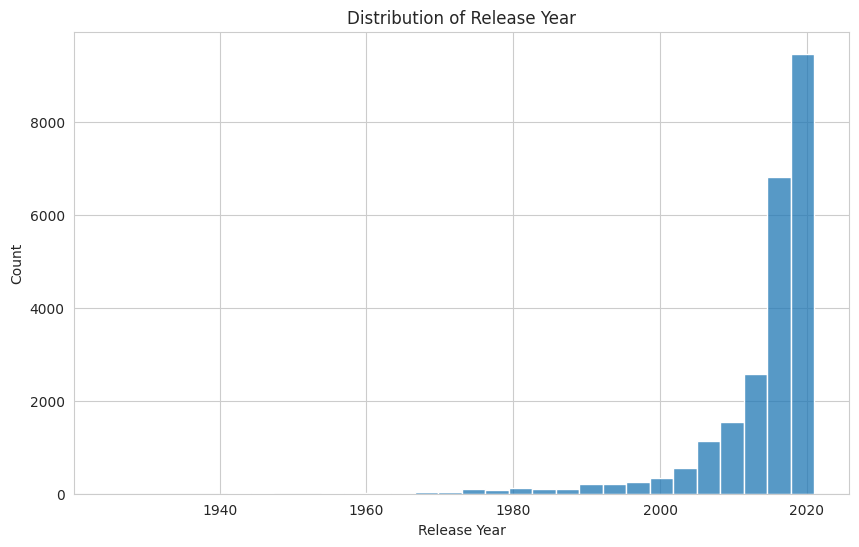

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data['release_year'], bins=30)
plt.title("Distribution of Release Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

As Netflix started expanding into producing its own shows and movies around late 2000s and early 2010s, there is no surprise that contents skyrockets during that period.

This growth should continue to maintain a modern and relevant catalog that can cater to chaning audience preferences

**Movies vs TV Shows**

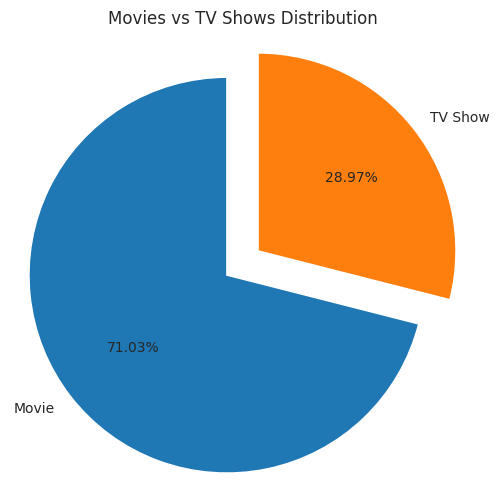

In [ ]:
type_counts = data['type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(type_counts,
        labels=type_counts.index,
        explode=(0.2,0),
        autopct='%.2f%%',
        startangle=90)

plt.title("Movies vs TV Shows Distribution")
plt.axis('equal')  # Makes it circular
plt.show()

Movies dominate the overall count, but TV shows still have a significant share on the platform.

**Rating Distribution**

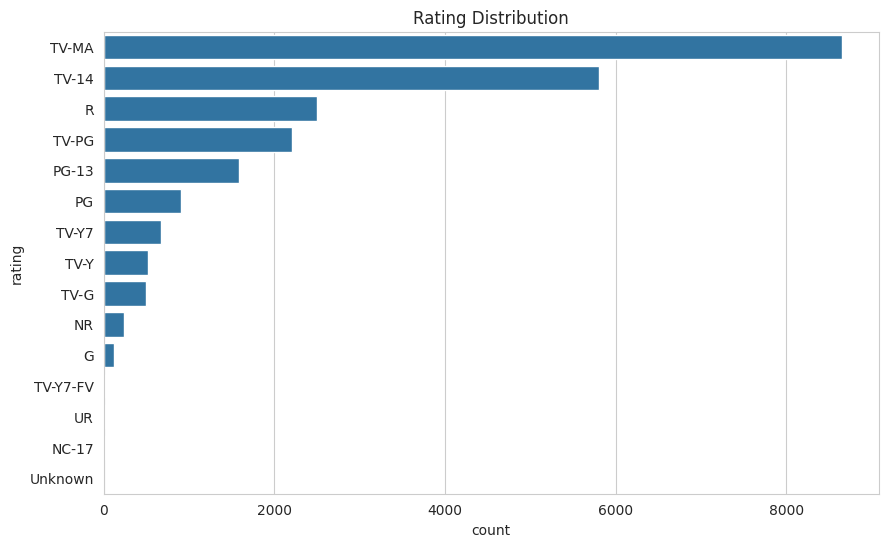

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(y='rating', data=data, order=data['rating'].value_counts().index)
plt.title("Rating Distribution")
plt.show()

TV-MA, TV-14, and R rated movies/tv shows toping the list suggests that Netflix is presenting itself as a content platform for mature, narrative driven(be it complex) and emotionally engaging type of entertainment. This shows how straming platforms have become more individual focused rather than family focused(TV appropriate) allowing consumption of these kind of content privately.

Targeting this demographic is essential for Netflix's growth by increasing user retention, bing worthy shows and ultimately subscription stability

**Addition of Content through Heatmap**

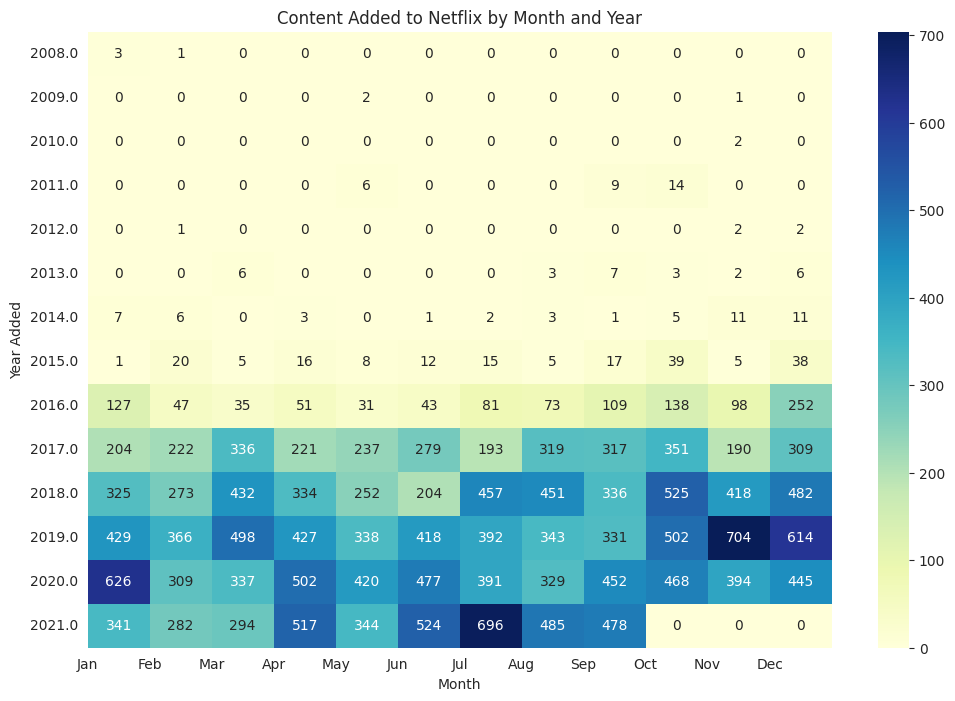

In [ ]:
pivot = pd.crosstab(data['year_added'], data['month_added'])

pivot = pivot.reindex(columns=range(1,13), fill_value=0)

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='d')

plt.xlabel("Month")
plt.ylabel("Year Added")
plt.title("Content Added to Netflix by Month and Year")

plt.xticks(ticks=range(12),
           labels=['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec'])

plt.show()

More and more content was added specifically after 2016, reaching its peak between 2019 and 2020, indicating an aggresive expansion.

The heatmap also indicated more content was added either mid-year or end of the year, meaning there were seasonal releases alligning with viewership patterns

**Type vs Year Added**

In [ ]:
data = data.reset_index(drop=True)

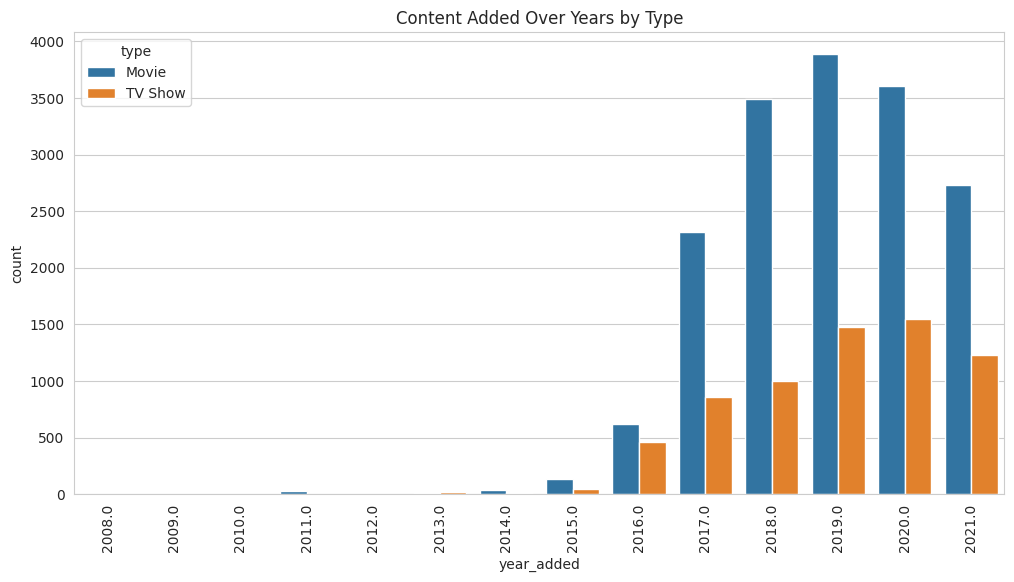

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='year_added', hue='type', data=data)
plt.xticks(rotation=90)
plt.title("Content Added Over Years by Type")
plt.show()

Movies were added more than TV shows but after 2016 there has been a surge in addition of TV series to the catalog suggesting a gradual shift toward series based content.

The decision of focusing on TV shows mean Netflix is targeting subscription stability and user retention as the nature of tv series helps in binge watching through episodes and seasons.

**Country vs Type (Market Strategy)**

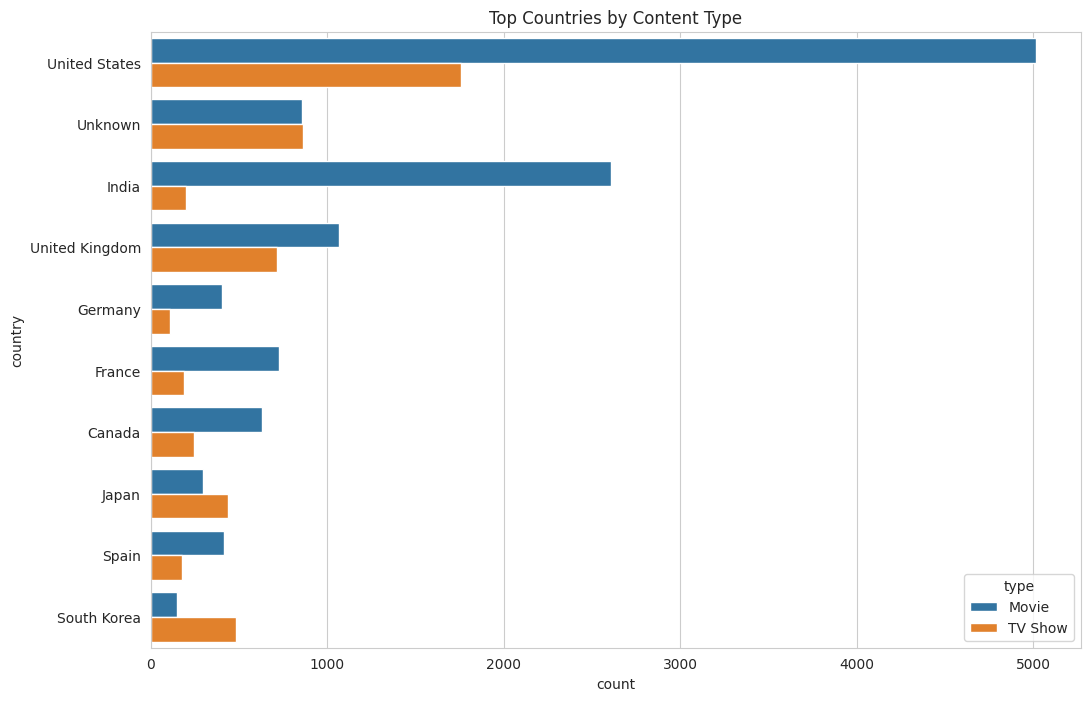

In [ ]:
top_countries = data['country'].value_counts().head(10).index
filtered = data[data['country'].isin(top_countries)]

plt.figure(figsize=(12,8))
sns.countplot(y='country', hue='type', data=filtered)
plt.title("Top Countries by Content Type")
plt.show()

United States, India and many other countries have produced more movies than TV shows, although US has also produced significant number of tv series. On the contrary South Korea and Japan has more TV shows suggesting increasing deamnd of K-Dramas.

Understanding the content preference in different countries is essential for increasing catalog in that country and catering to that domestic market.

**Duration Box Plot**

In [ ]:
movies['duration_int'] = movies['duration'].str.extract(r'(\d+)').astype(float)

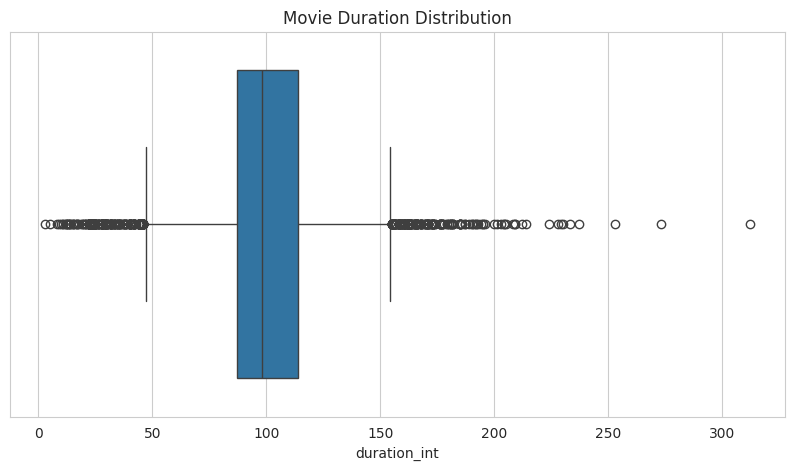

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x=movies['duration_int'])
plt.title("Movie Duration Distribution")
plt.show()

**Movie Duration Histogram**

In [ ]:
movies = data_original[data_original['type'] == 'Movie'].copy()

movies['duration_int'] = movies['duration'].str.extract(r'(\d+)').astype(float)

In [ ]:
min_duration = movies['duration_int'].min()
max_duration = movies['duration_int'].max()
mean_duration = movies['duration_int'].mean()
median_duration = movies['duration_int'].median()

print("Duration Summary Statistics:")
print(f"Minimum duration: {min_duration} min")
print(f"Maximum duration: {max_duration} min")
print(f"Mean duration: {mean_duration:.2f} min")
print(f"Median duration: {median_duration:.2f} min")

Duration Summary Statistics:
Minimum duration: 3.0 min
Maximum duration: 312.0 min
Mean duration: 99.58 min
Median duration: 98.00 min


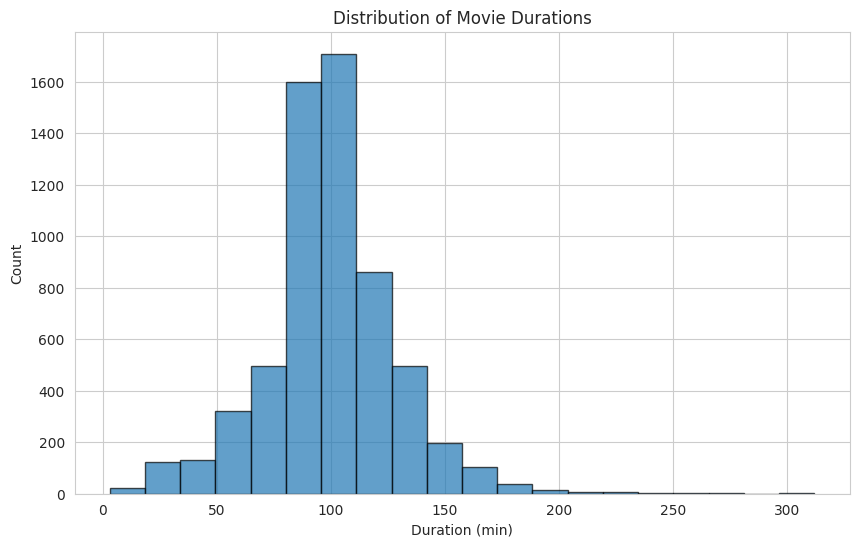

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(movies['duration_int'], bins=20, edgecolor='black', alpha=0.7)

plt.xlabel("Duration (min)")
plt.ylabel("Count")
plt.title("Distribution of Movie Durations")
plt.show()

The majority of movie durations cluster between 80 and 120 minutes, with few extreme outliers exceeding 200 minutes.

This indicates that Netflix predominantly follows industry-standard movie lengths, aligning with typical viewer attention spans.

**TV Show Seasons distributions**

In [ ]:
data_original = pd.read_csv("final_vg.csv")

In [ ]:
tv_shows = data_original[data_original['type'] == 'TV Show'].copy()

# Extract numeric seasons
tv_shows['season_count'] = tv_shows['duration'].str.extract(r'(\d+)').astype(float)

In [ ]:
tv_shows['season_category'] = tv_shows['season_count'].apply(
    lambda x: '6+ Seasons' if x >= 6 else f"{int(x)} Season" if x == 1 else f"{int(x)} Seasons"
)

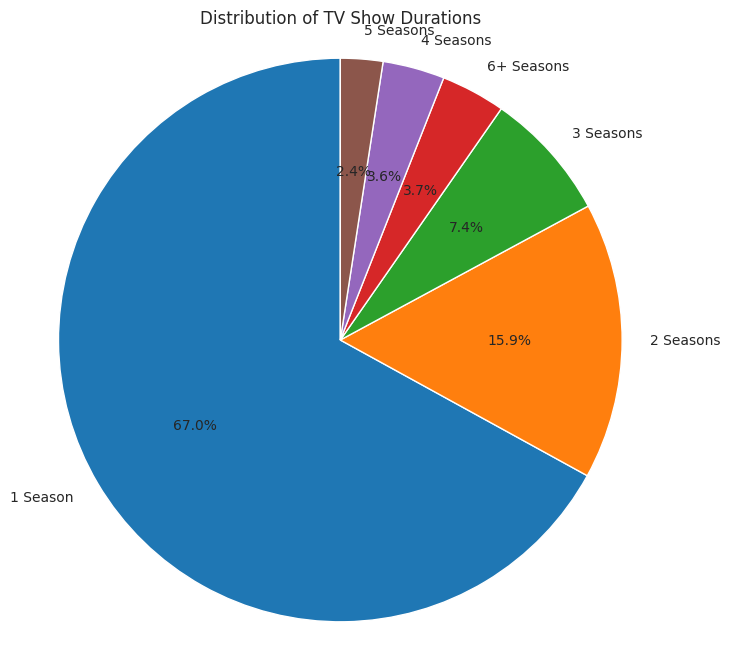

In [ ]:
season_counts = tv_shows['season_category'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(season_counts,
        labels=season_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribution of TV Show Durations")
plt.axis('equal')
plt.show()

More than two-third of the total TV Shows have only one season which means either first show determines if it connects with the audience and deserves a second or more episode or it means people dont have that much of patience to end a storyline perhaps after more than 2 or 3 seasons.

This pie chart shows that peoples attention span is decreasing and one season shows connect more with the audience than multiple season shows, and performance of first season should determine if the second season is worth or not.

# 6. Insights

6.1 Netflix significantly expanded its library after 2016, peaking between 2019 and 2020

6.2 Movies dominate the catalog but there is increase in production of TV Shows.

6.3 Most of the content is produced in United States, India and United Kingdom.

6.4 Most prominent genres were international movies/tv shows followed by drama and comedy.

6.5 Movies were mostly 90 to 110 minutes long while most of the TV shows had only 1 season.

# 7. Recommendations

7.1 Invest more in original TV series to strengthen subscriber retention.

7.2 Produce more localised content to cater markets beyond the english speaking one.

7.3 Continue focusing on high deamand genres like drama, comedy and providng international content.

7.4 When the movie and TV Series is released plays a huge role in its success so that should be considered.